### GPU Verification

This step checks whether a GPU is available in the Colab environment using the `nvidia-smi` command. GPU acceleration is required to efficiently train the Deformable 3D Gaussians model, as the training process relies heavily on CUDA-based operations. If a GPU is not available, the training process would be significantly slower or may fail due to missing CUDA support.

In [1]:
!nvidia-smi

Sat Apr 25 18:43:08 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### Repository Setup

This step clones the forked Deformable 3D Gaussians repository into the Colab environment. The repository contains the implementation used for both Experiment 1 and Experiment 2. Working with a forked version allows modifications to be made without affecting the original source code, which is required for conducting custom experiments.

In [2]:
%cd /content

!git clone https://github.com/YashPatel2395/CS_547_Deformable-3D-Gaussians-Public_pately1.git

/content
Cloning into 'CS_547_Deformable-3D-Gaussians-Public_pately1'...
remote: Enumerating objects: 176, done.
remote: Counting objects: 100% (60/60), done.
remote: Compressing objects: 100% (42/42), done.
remote: Total 176 (delta 28), reused 18 (delta 18), pack-reused 116 (from 1)
Receiving objects: 100% (176/176), 21.57 MiB | 22.80 MiB/s, done.
Resolving deltas: 100% (60/60), done.


### Repository Initialization and Submodule Setup

This step navigates into the cloned repository and switches to the `original-work` branch, which contains the working version used for experimentation. It also initializes and updates all submodules required by the project. These submodules include external dependencies such as CUDA-based components for Gaussian rasterization and nearest neighbor computations, which are essential for training and rendering.

In [3]:
%cd /content/CS_547_Deformable-3D-Gaussians-Public_pately1

!git checkout original-work
!git submodule update --init --recursive

/content/CS_547_Deformable-3D-Gaussians-Public_pately1
Branch 'original-work' set up to track remote branch 'original-work' from 'origin'.
Switched to a new branch 'original-work'
Submodule 'submodules/depth-diff-gaussian-rasterization' (https://github.com/ingra14m/diff-gaussian-rasterization-extentions) registered for path 'submodules/depth-diff-gaussian-rasterization'
Submodule 'submodules/simple-knn' (https://gitlab.inria.fr/bkerbl/simple-knn.git) registered for path 'submodules/simple-knn'
Cloning into '/content/CS_547_Deformable-3D-Gaussians-Public_pately1/submodules/depth-diff-gaussian-rasterization'...
Cloning into '/content/CS_547_Deformable-3D-Gaussians-Public_pately1/submodules/simple-knn'...
Submodule path 'submodules/depth-diff-gaussian-rasterization': checked out 'd595eacabe86334988cd4273e0aaa07858b5ad2e'
Submodule 'third_party/glm' (https://github.com/g-truc/glm.git) registered for path 'submodules/depth-diff-gaussian-rasterization/third_party/glm'
Cloning into '/content/

### Dependency Installation

This step installs the required Python libraries used throughout the project. These dependencies support various parts of the pipeline, including point cloud handling (`plyfile`), image processing (`opencv-python`, `imageio`), visualization (`matplotlib`), and progress tracking (`tqdm`). These libraries are necessary to ensure smooth execution of training, rendering, and result visualization.

In [4]:
!pip install plyfile tqdm opencv-python imageio imageio-ffmpeg matplotlib -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 3.1 MB/s eta 0:00:00


### Fixing CUDA Compilation Issue (simple_knn)

This step ensures compatibility of the `simple_knn` CUDA module with the current environment. The `#include <cfloat>` header is added to the CUDA source file if it is not already present. This resolves a compilation issue related to missing floating-point definitions when building the extension in Colab. Without this fix, the `simple_knn` module may fail to compile, preventing the training pipeline from running.

In [5]:
!grep -q "#include <cfloat>" submodules/simple-knn/simple_knn.cu || sed -i '1i #include <cfloat>' submodules/simple-knn/simple_knn.cu

### Building and Installing simple_knn Module

This step builds and installs the `simple_knn` module, which is a CUDA-based extension used for efficient nearest neighbor computations. It is a critical component of the Deformable 3D Gaussians pipeline, as it supports spatial operations required during training. Installing it compiles the CUDA code into a usable Python extension for GPU-accelerated execution.

In [6]:
%cd /content/CS_547_Deformable-3D-Gaussians-Public_pately1/submodules/simple-knn
!pip install . -q

/content/CS_547_Deformable-3D-Gaussians-Public_pately1/submodules/simple-knn
  Preparing metadata (setup.py) ... done


### Fixing Library Path for CUDA Dependencies

This step updates the `LD_LIBRARY_PATH` environment variable to include the directory containing PyTorch's shared libraries. This ensures that compiled CUDA extensions (such as `simple_knn` and the rasterization module) can locate required dependencies like `libc10.so` at runtime. Without this adjustment, import errors may occur due to missing shared libraries.

In [8]:
import os, torch

torch_lib = os.path.join(os.path.dirname(torch.__file__), "lib")

os.environ["LD_LIBRARY_PATH"] = torch_lib + ":" + os.environ.get("LD_LIBRARY_PATH", "")

print(os.environ["LD_LIBRARY_PATH"])

/usr/local/lib/python3.12/dist-packages/torch/lib:/usr/lib64-nvidia


### Verifying simple_knn Installation

This step imports the compiled `simple_knn` CUDA extension to verify that it was built and installed correctly. Successfully importing the module confirms that the compilation process completed without errors and that all required CUDA dependencies are properly linked. This validation is important before proceeding to training, as failures here would break the pipeline later.

In [9]:
import simple_knn._C
print("simple_knn imported successfully")

simple_knn imported successfully


### Building and Installing Gaussian Rasterization Module

This step builds and installs the `diff_gaussian_rasterization` module, which is responsible for rendering the Gaussian-based scene representation. It is a CUDA-accelerated component that performs efficient rasterization of 3D Gaussians into 2D images. This module is essential for both training and rendering, as it enables fast projection of the learned Gaussian primitives onto the image plane.

In [10]:
%cd /content/CS_547_Deformable-3D-Gaussians-Public_pately1/submodules/diff-gaussian-rasterization
!pip install . -q

[Errno 2] No such file or directory: '/content/CS_547_Deformable-3D-Gaussians-Public_pately1/submodules/diff-gaussian-rasterization'
/content/CS_547_Deformable-3D-Gaussians-Public_pately1/submodules/simple-knn
  Preparing metadata (setup.py) ... done


### Verifying Submodule Structure

This step inspects the directory structure of the `submodules` folder to confirm that all required components have been properly initialized. It helps verify the presence of critical modules such as `simple-knn` and `diff-gaussian-rasterization`. This check ensures that the repository setup is complete before proceeding with further installation and execution steps.

In [11]:
%cd /content/CS_547_Deformable-3D-Gaussians-Public_pately1
!find submodules -maxdepth 2 -type d

/content/CS_547_Deformable-3D-Gaussians-Public_pately1
submodules
submodules/depth-diff-gaussian-rasterization
submodules/depth-diff-gaussian-rasterization/cuda_rasterizer
submodules/depth-diff-gaussian-rasterization/diff_gaussian_rasterization
submodules/depth-diff-gaussian-rasterization/third_party
submodules/simple-knn
submodules/simple-knn/simple_knn
submodules/simple-knn/simple_knn.egg-info
submodules/simple-knn/build


### Navigating to Rasterization Module Source

This step moves into the `depth-diff-gaussian-rasterization` submodule directory, which contains the source code for the Gaussian rasterization component. Accessing this directory is required to build and install the module correctly, as the compilation process must be executed from within the module’s root directory.

In [12]:
%cd /content/CS_547_Deformable-3D-Gaussians-Public_pately1/submodules/depth-diff-gaussian-rasterization

/content/CS_547_Deformable-3D-Gaussians-Public_pately1/submodules/depth-diff-gaussian-rasterization


### Installing Rasterization Module

This step compiles and installs the `depth-diff-gaussian-rasterization` module from its source directory. The installation process builds the CUDA extension and makes it available as a Python package. This module is required for rendering Gaussian primitives during both training and evaluation, enabling efficient GPU-based projection of 3D data into image space.

In [13]:
!pip install . -q

  Preparing metadata (setup.py) ... done


### Re-entering Rasterization Module Directory

This step ensures that the working directory is correctly set to the `depth-diff-gaussian-rasterization` module before performing further operations such as installation or debugging. Reconfirming the directory helps avoid path-related errors during subsequent commands.

In [15]:
%cd /content/CS_547_Deformable-3D-Gaussians-Public_pately1/submodules/depth-diff-gaussian-rasterization

/content/CS_547_Deformable-3D-Gaussians-Public_pately1/submodules/depth-diff-gaussian-rasterization


### Rebuilding Rasterization Module from Scratch

This step performs a clean reinstallation of the `diff_gaussian_rasterization` module. It removes previous build artifacts and cached installations, uninstalls any existing version of the module, and then reinstalls it with a fresh build. This process resolves issues related to incomplete or incorrect compilation, such as missing CUDA extensions or import errors. A clean rebuild ensures that the module is compiled correctly and fully compatible with the current environment.

In [16]:
!rm -rf build *.egg-info diff_gaussian_rasterization.egg-info
!pip uninstall diff-gaussian-rasterization -y
!pip install . --no-cache-dir --force-reinstall -v

Found existing installation: diff_gaussian_rasterization 0.0.0
Uninstalling diff_gaussian_rasterization-0.0.0:
  Successfully uninstalled diff_gaussian_rasterization-0.0.0
Using pip 24.1.2 from /usr/local/lib/python3.12/dist-packages/pip (python 3.12)
Processing /content/CS_547_Deformable-3D-Gaussians-Public_pately1/submodules/depth-diff-gaussian-rasterization
  Running command python setup.py egg_info
  running egg_info
  creating /tmp/pip-pip-egg-info-5ig4iea5/diff_gaussian_rasterization.egg-info
  writing /tmp/pip-pip-egg-info-5ig4iea5/diff_gaussian_rasterization.egg-info/PKG-INFO
  writing dependency_links to /tmp/pip-pip-egg-info-5ig4iea5/diff_gaussian_rasterization.egg-info/dependency_links.txt
  writing top-level names to /tmp/pip-pip-egg-info-5ig4iea5/diff_gaussian_rasterization.egg-info/top_level.txt
  writing manifest file '/tmp/pip-pip-egg-info-5ig4iea5/diff_gaussian_rasterization.egg-info/SOURCES.txt'
  W0425 19:03:36.822000 18882 torch/utils/cpp_extension.py:659] Attempted

### Returning to Repository Root Directory

This step navigates back to the main repository directory after completing the installation of submodules. Returning to the root directory is necessary to execute project-level scripts such as training and rendering, which are located at the top level of the repository.

In [17]:
%cd /content/CS_547_Deformable-3D-Gaussians-Public_pately1

/content/CS_547_Deformable-3D-Gaussians-Public_pately1


### Verifying Rasterization Module Installation

This step imports the `diff_gaussian_rasterization` module to confirm that it has been successfully built and installed. Since this module contains compiled CUDA code, successful import verifies that the compilation completed correctly and that all required GPU dependencies are properly linked. This check ensures the rendering and training pipeline can proceed without runtime errors.

In [18]:
import diff_gaussian_rasterization
print("rasterizer imported successfully")

rasterizer imported successfully


### Ensuring Correct Working Directory

This step confirms that the current working directory is set to the root of the repository before proceeding to dataset setup and training. Maintaining the correct working directory is essential because subsequent commands rely on relative paths to access data, scripts, and output folders.

In [19]:
%cd /content/CS_547_Deformable-3D-Gaussians-Public_pately1

/content/CS_547_Deformable-3D-Gaussians-Public_pately1


### Reinforcing CUDA Library Path Configuration

This step re-applies the `LD_LIBRARY_PATH` configuration to ensure that all CUDA-related shared libraries from PyTorch are accessible. This is done again before proceeding further to prevent runtime issues during dataset processing, training, or rendering. Reconfirming this setup helps maintain stability of compiled extensions such as `simple_knn` and the rasterization module.

In [20]:
import os, torch

torch_lib = os.path.join(os.path.dirname(torch.__file__), "lib")
os.environ["LD_LIBRARY_PATH"] = torch_lib + ":" + os.environ.get("LD_LIBRARY_PATH", "")

print(os.environ["LD_LIBRARY_PATH"])

/usr/local/lib/python3.12/dist-packages/torch/lib:/usr/local/lib/python3.12/dist-packages/torch/lib:/usr/lib64-nvidia


### Configuring Kaggle API Credentials

This step sets up the Kaggle API by creating the required directory, copying the `kaggle.json` credentials file, and applying appropriate permissions. The Kaggle API is used to download the D-NeRF dataset, and proper configuration is necessary to authenticate and access the dataset programmatically. Without this setup, dataset download would fail due to missing authorization.

In [21]:
!mkdir -p ~/.kaggle
!cp /content/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

### Verifying Kaggle Dataset Access

This step queries Kaggle to search for datasets related to "D-NeRF" and confirms that the API is properly configured. Successfully retrieving results verifies that authentication is working correctly and that the environment is ready to download the required dataset.

In [22]:
!kaggle datasets list -s dnerf

ref                              title                   size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-------------------------------  ----------------  ----------  --------------------------  -------------  ---------  ---------------  
lubeshsharma/dnerf-slim-yaml     dnerf_slim.yaml          651  2024-01-30 09:32:33.363000              1          1  0.25             
sinngamkhaidem/ednerf-src-files  ednerf src files   849357752  2026-04-25 15:15:24.443000              0          1  0.25             
fsr3340/dnerf                    D-nerf             339193002  2021-07-26 12:18:39.037000             97          4  0.0625           


### Downloading and Preparing D-NeRF Dataset

This step navigates to the repository root, creates a `data` directory, and downloads the D-NeRF dataset using the Kaggle API. The dataset is then extracted into the appropriate location for training. The D-NeRF dataset contains dynamic scenes with corresponding transformation files, which are required for training and evaluating the Deformable 3D Gaussians model.

In [23]:
%cd /content/CS_547_Deformable-3D-Gaussians-Public_pately1
!mkdir -p data
%cd data

!kaggle datasets download -d fsr3340/dnerf --unzip

/content/CS_547_Deformable-3D-Gaussians-Public_pately1
/content/CS_547_Deformable-3D-Gaussians-Public_pately1/data
Dataset URL: https://www.kaggle.com/datasets/fsr3340/dnerf
License(s): unknown
100% 323M/323M [00:03<00:00, 110MB/s]



### Locating Dataset Structure Files

This step searches for the `transforms_train.json` file within the dataset directory to verify its structure. This file is essential because it defines camera poses and scene information required by the training pipeline. Identifying its location helps ensure that the dataset is organized correctly and can be properly recognized by the model.

In [24]:
!find . -maxdepth 4 -type f -name "transforms_train.json"

./data/data/bouncingballs/transforms_train.json
./data/data/standup/transforms_train.json
./data/data/jumpingjacks/transforms_train.json
./data/data/trex/transforms_train.json
./data/data/hook/transforms_train.json
./data/data/mutant/transforms_train.json
./data/data/hellwarrior/transforms_train.json
./data/data/lego/transforms_train.json


### Reinforcing Dataset Structure Correction

This step repeats the dataset restructuring command to ensure that the `hook` scene directory is correctly placed in the expected location. This helps confirm that the dataset structure aligns with the requirements of the training pipeline and avoids potential path-related errors.

In [25]:
!mv data/data/hook .

### Verifying Scene Directory Contents

This step lists the contents of the `hook` scene directory to confirm that it contains the required files and subfolders, such as `transforms_train.json`, `transforms_test.json`, and image directories. This verification ensures that the dataset has been correctly reorganized and is ready for use in the training pipeline.

In [26]:
!ls hook

test   transforms_test.json   transforms_val.json
train  transforms_train.json  val


### Locating Initialization Parameter for Gaussian Points

This step searches the codebase to locate where the initial number of Gaussian points is defined. Identifying this location is necessary for modifying the model initialization in Experiment 2. By finding the exact line where the random point cloud is generated, we can adjust the number of initial Gaussian primitives to study its impact on reconstruction quality and efficiency.

In [27]:
%cd /content/CS_547_Deformable-3D-Gaussians-Public_pately1

!grep -R "Generating random point cloud" -n .

/content/CS_547_Deformable-3D-Gaussians-Public_pately1
./scene/dataset_readers.py:287:        print(f"Generating random point cloud ({num_pts})...")
./scene/dataset_readers.py:376:        print(f"Generating random point cloud ({num_pts})...")
./scene/dataset_readers.py:577:        print(f"Generating random point cloud ({num_pts})...")


### Inspecting Code Sections for Gaussian Initialization

This step displays relevant portions of the `dataset_readers.py` file to examine how the initial Gaussian point cloud is generated. By reviewing these code sections, we can identify the exact location and logic used to define the number of initial points (`num_pts`). This inspection is necessary to ensure that modifications for Experiment 2 are applied correctly to the appropriate part of the pipeline.

In [28]:
!sed -n '260,300p' scene/dataset_readers.py
!sed -n '350,390p' scene/dataset_readers.py
!sed -n '560,590p' scene/dataset_readers.py


            cam_infos.append(CameraInfo(uid=idx, R=R, T=T, FovY=FovY, FovX=FovX, image=image,
                                        image_path=image_path, image_name=image_name, width=image.size[
                                            0],
                                        height=image.size[1], fid=frame_time))

    return cam_infos


def readNerfSyntheticInfo(path, white_background, eval, extension=".png"):
    print("Reading Training Transforms")
    train_cam_infos = readCamerasFromTransforms(
        path, "transforms_train.json", white_background, extension)
    print("Reading Test Transforms")
    test_cam_infos = readCamerasFromTransforms(
        path, "transforms_test.json", white_background, extension)

    if not eval:
        train_cam_infos.extend(test_cam_infos)
        test_cam_infos = []

    nerf_normalization = getNerfppNorm(train_cam_infos)

    ply_path = os.path.join(path, "points3d.ply")
    if not os.path.exists(ply_path):
        # Since this data s

### Reinforcing Modification of Gaussian Initialization

This step repeats the update to ensure that all occurrences of the initial Gaussian point count in the code are correctly modified from 100,000 to 50,000. This guarantees consistency across different dataset handling functions and prevents unintended use of the original initialization value during training.

In [29]:
!sed -i 's/num_pts = 100_000/num_pts = 50_000/' scene/dataset_readers.py
!sed -i 's/num_pts = 100000/num_pts = 50000/' scene/dataset_readers.py

### Verifying Gaussian Point Count Modification

This step searches the source code to confirm that all occurrences of the initial Gaussian point count (`num_pts`) have been successfully updated to 50,000. This verification ensures that the modification for Experiment 2 has been correctly applied and that the training process will use the updated initialization.

In [30]:
!grep -n "num_pts" scene/dataset_readers.py

286:        num_pts = 50_000
287:        print(f"Generating random point cloud ({num_pts})...")
290:        xyz = np.random.random((num_pts, 3)) * 2.6 - 1.3
291:        shs = np.random.random((num_pts, 3)) / 255.0
293:            shs), normals=np.zeros((num_pts, 3)))
375:        num_pts = 50_000
376:        print(f"Generating random point cloud ({num_pts})...")
379:        xyz = np.random.random((num_pts, 3)) * 2.6 - 1.3
380:        shs = np.random.random((num_pts, 3)) / 255.0
382:            shs), normals=np.zeros((num_pts, 3)))
494:        num_pts = xyz.shape[0]
495:        shs = np.random.random((num_pts, 3)) / 255.0
497:            shs), normals=np.zeros((num_pts, 3)))
576:        num_pts = 50_000
577:        print(f"Generating random point cloud ({num_pts})...")
580:        xyz = np.random.random((num_pts, 3)) * 2.6 - 1.3
581:        shs = np.random.random((num_pts, 3)) / 255.0
583:            shs), normals=np.zeros((num_pts, 3)))


### Removing Cached Point Cloud

This step deletes the existing `points3d.ply` file to ensure that the modified Gaussian initialization is applied during training. If this file is not removed, the training pipeline will reuse the previously generated point cloud instead of creating a new one with the updated number of points. Removing this file guarantees that the experiment uses the modified initialization defined in the code.

In [32]:
!rm data/hook/points3d.ply

rm: cannot remove 'data/hook/points3d.ply': No such file or directory


### Training Model with Modified Initialization (Experiment 2)

This step runs the training process using the modified configuration where the initial number of Gaussian points has been reduced to 50,000. The model is trained on the `hook` scene for 5,000 iterations, and evaluation is performed at selected checkpoints. The results from this training will be compared with the baseline experiment to analyze the impact of reduced initialization on reconstruction quality.

In [33]:
!python train.py \
  -s data/hook \
  -m output/hook_5000_mod \
  --iterations 5000 \
  --test_iterations 1000 3000 5000 \
  --save_iterations 2500 5000 \
  --eval

2026-04-25 19:37:04.273478: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777145824.295233   27391 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777145824.302311   27391 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777145824.320703   27391 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777145824.320750   27391 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777145824.320754   27391 computation_placer.cc:177] computation placer alr

### Explanation
Rendering outputs using the trained model.


In [37]:
!python render.py \
  -m output/hook_5000_mod \
  --iteration 5000

Looking for config file in output/hook_5000_mod/cfg_args
Config file found: output/hook_5000_mod/cfg_args
Rendering output/hook_5000_mod
Loading trained model at iteration 5000 [25/04 20:25:19]
Found transforms_train.json file, assuming Blender data set! [25/04 20:25:19]
Reading Training Transforms [25/04 20:25:19]
Reading Test Transforms [25/04 20:25:24]
Loading Training Cameras [25/04 20:25:25]
Loading Test Cameras [25/04 20:25:27]
Rendering progress: 100% 100/100 [00:17<00:00,  5.62it/s]
Rendering progress: 100% 100/100 [00:01<00:00, 70.88it/s]
Test FPS: 72.83742, Num. of GS: 30484 [25/04 20:25:46]
Rendering progress: 100% 20/20 [00:04<00:00,  4.80it/s]
Rendering progress: 100% 20/20 [00:00<00:00, 57.84it/s]
Test FPS: 61.38449, Num. of GS: 30484 [25/04 20:25:51]


### Qualitative Evaluation of Modified Model

This step visualizes the rendered output from the model trained with 50,000 initial Gaussian points and compares it with the corresponding ground truth image. This qualitative comparison helps assess how well the modified model reconstructs scene structure, appearance, and motion. Observing similarities between the rendered image and ground truth provides insight into the effectiveness of the reduced initialization in maintaining reconstruction quality.

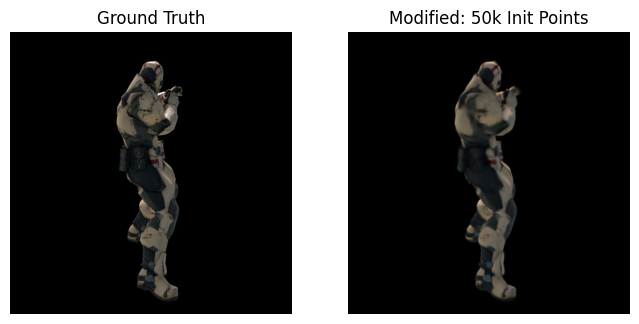

In [35]:
from PIL import Image
import matplotlib.pyplot as plt

f = "00009.png"

gt = Image.open(f"output/hook_5000_mod/test/ours_5000/gt/{f}")
mod = Image.open(f"output/hook_5000_mod/test/ours_5000/renders/{f}")

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(gt)
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mod)
plt.title("Modified: 50k Init Points")
plt.axis("off")

plt.show()

### Extended Training with Reduced Initialization

This step performs an extended training run using 50,000 initial Gaussian points for 10,000 iterations. The goal of this experiment is to evaluate whether increasing the training duration can compensate for the reduced initialization size. By comparing these results with both the baseline and the 5,000-iteration modified model, we can analyze the trade-off between model complexity and training time in achieving high reconstruction quality.

In [38]:
!python train.py \
  -s data/hook \
  -m output/hook_10000_mod \
  --iterations 10000 \
  --test_iterations 5000 10000 \
  --save_iterations 5000 10000 \
  --eval

2026-04-25 20:36:26.222223: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777149386.243563   42205 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777149386.250894   42205 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777149386.269343   42205 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777149386.269382   42205 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777149386.269386   42205 computation_placer.cc:177] computation placer alr

### Explanation
Rendering outputs using the trained model.


In [39]:
!python render.py \
  -m output/hook_10000_mod \
  --iteration 10000

Looking for config file in output/hook_10000_mod/cfg_args
Config file found: output/hook_10000_mod/cfg_args
Rendering output/hook_10000_mod
Loading trained model at iteration 10000 [25/04 20:48:25]
Found transforms_train.json file, assuming Blender data set! [25/04 20:48:25]
Reading Training Transforms [25/04 20:48:25]
Reading Test Transforms [25/04 20:48:30]
Loading Training Cameras [25/04 20:48:31]
Loading Test Cameras [25/04 20:48:32]
Rendering progress: 100% 100/100 [00:19<00:00,  5.07it/s]
Rendering progress: 100% 100/100 [00:02<00:00, 37.29it/s]
Test FPS: 38.03885, Num. of GS: 55074 [25/04 20:48:55]
Rendering progress: 100% 20/20 [00:03<00:00,  5.66it/s]
Rendering progress: 100% 20/20 [00:00<00:00, 33.19it/s]
Test FPS: 35.31697, Num. of GS: 55074 [25/04 20:48:59]


### Comparative Analysis of Training Duration

This step compares the reconstruction quality of models trained with 50,000 initial Gaussian points at different iteration counts (5,000 vs 10,000). The rendered outputs are shown alongside the ground truth image to evaluate improvements in visual quality. This comparison demonstrates how increased training iterations impact reconstruction accuracy and helps determine whether longer training can compensate for reduced model complexity.

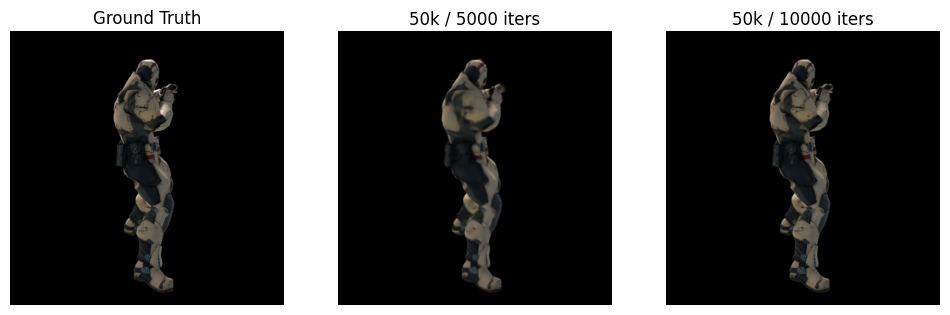

In [40]:
from PIL import Image
import matplotlib.pyplot as plt

f = "00009.png"

gt = Image.open(f"output/hook_10000_mod/test/ours_10000/gt/{f}")
mod_5000 = Image.open(f"output/hook_5000_mod/test/ours_5000/renders/{f}")
mod_10000 = Image.open(f"output/hook_10000_mod/test/ours_10000/renders/{f}")

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(gt)
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(mod_5000)
plt.title("50k / 5000 iters")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(mod_10000)
plt.title("50k / 10000 iters")
plt.axis("off")

plt.show()